<a href="https://colab.research.google.com/github/HiyoriVn/CSE_Machine-Learning/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from __future__ import division, print_function, unicode_literals
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import Image

In [2]:
def grad(x):
    return 2*x+ 5*np.cos(x)

def cost(x):
    return x**2 + 5*np.sin(x)

def myGD1(eta, x0):
    x = [x0]
    for it in range(100):
        x_new = x[-1] - eta*grad(x[-1])
        if abs(grad(x_new)) < 1e-3:
            break
        x.append(x_new)
    return (x, it)

In [29]:
def grad(x):
    return x**2 - 1

def cost(x):
    return (1/3)*x**3 - x
def myGD1(eta, x0):
    x = [x0]
    for it in range(100):
        x_new = x[-1] - eta*grad(x[-1])
        if abs(grad(x_new)) < 1e-3:
            break
        x.append(x_new)
    return (x, it)

In [31]:
eta = 0.1
x0_a = 0
x0_b = 2

x_history_a, it_a = myGD1(eta, x0_a)
x_history_b, it_b = myGD1(eta, x0_b)

x_plot = np.linspace(-3, 3, 200)
y_plot = cost(x_plot)

print("Case x0=-2: số vòng lặp =", it_a, ", x cuối =", x_history_a[-1])
print("Case x0=2:  số vòng lặp =", it_b, ", x cuối =", x_history_b[-1])

Case x0=-2: số vòng lặp = 37 , x cuối = 0.9993864536092386
Case x0=2:  số vòng lặp = 31 , x cuối = 1.0005945969188843


In [19]:
eta = 0.1
x0_a = -5
x0_b = 5

x_history_a, it_a = myGD1(eta, x0_a)
x_history_b, it_b = myGD1(eta, x0_b)

x_plot = np.linspace(-6, 6, 200)
y_plot = cost(x_plot)

print("Case x0=-5: số vòng lặp =", it_a, ", x cuối =", x_history_a[-1])
print("Case x0=5:  số vòng lặp =", it_b, ", x cuối =", x_history_b[-1])

Case x0=-5: số vòng lặp = 11 , x cuối = -1.1106667365268623
Case x0=5:  số vòng lặp = 29 , x cuối = -1.1103410483948122


In [32]:
def make_anim(x0, eta, x_history, it):
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(x_plot, y_plot, 'b-')
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 30)
    ax.set_title(r'$f(x) = x^2 + 5\sin(x)$; $x_0 = %d$; $\eta = %.2f$' % (x0, eta))

    point_curr, = ax.plot([], [], 'ro', markersize=8)
    point_prev, = ax.plot([], [], 'ko', markersize=8)
    text = ax.text(0.5, -0.12, '', transform=ax.transAxes, ha='center', va='top', fontsize=10)
    fig.subplots_adjust(bottom=0.15)

    def init():
        point_curr.set_data([], [])
        point_prev.set_data([], [])
        text.set_text('')
        return point_curr, point_prev, text

    def update(frame):
        x_curr = x_history[frame]
        point_curr.set_data([x_curr], [cost(x_curr)])
        if frame > 0:
            x_prev = x_history[frame - 1]
            point_prev.set_data([x_prev], [cost(x_prev)])
        text.set_text('iter %d/%d: cost = %.2f, grad = %.4f' %
                       (frame, it, cost(x_curr), grad(x_curr)))
        return point_curr, point_prev, text

    anim = animation.FuncAnimation(
        fig, update, frames=len(x_history),
        init_func=init, interval=400, blit=True, repeat=True
    )
    plt.close(fig)
    return anim

In [33]:
anim_a = make_anim(x0_a, eta, x_history_a, it_a)
anim_b = make_anim(x0_b, eta, x_history_b, it_b)

anim_a.save('gd_a.gif', writer='pillow', fps=3)
anim_b.save('gd_b.gif', writer='pillow', fps=3)


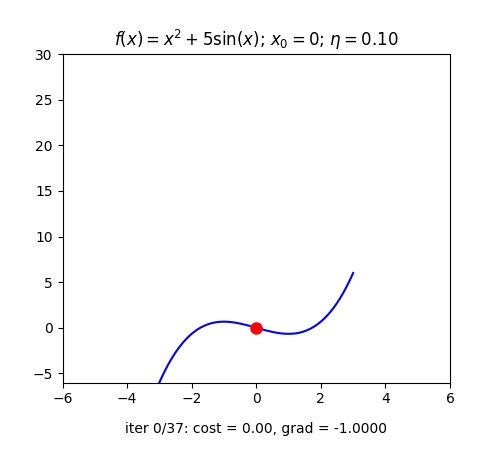
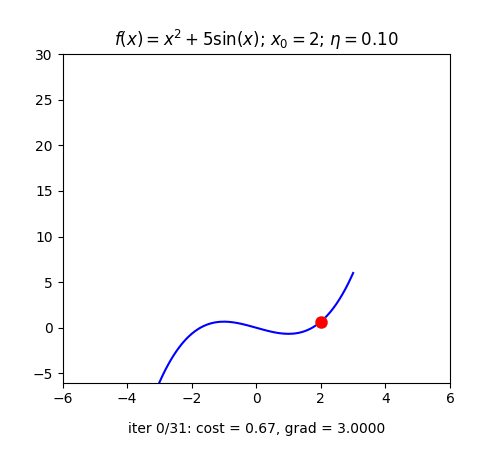

In [34]:
import base64
from IPython.display import HTML

def gif_to_b64(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('ascii')

b64_a = gif_to_b64('gd_a.gif')
b64_b = gif_to_b64('gd_b.gif')

html = f'''
<div style="display:flex; gap:10px;">
    <img src="data:image/gif;base64,{b64_a}" style="width:48%;">
    <img src="data:image/gif;base64,{b64_b}" style="width:48%;">
</div>
'''
HTML(html)